In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool, global_max_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_networkx
import networkx as nx
import numpy as np
import random
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import StepLR

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [60]:
class GSNTransform:
    def __call__(self, data):
        g = to_networkx(data, to_undirected=True)
        num_nodes = data.num_nodes
        
        tri_counts = nx.triangles(g) 
        basis = nx.cycle_basis(g)
        basis_counts = {i: 0 for i in range(num_nodes)}
        for cycle in basis:
            if len(cycle) <= 4: 
                for node in cycle:
                    basis_counts[node] += 1
                    
        feats = []
        for i in range(num_nodes):
            t_c = tri_counts.get(i, 0) / 10.0
            b_c = basis_counts.get(i, 0) / 10.0
            feats.append([float(t_c), float(b_c)])
            
        struct_feats = torch.tensor(feats, dtype=torch.float)
        
        if data.x is not None:
            data.x = torch.cat([data.x, struct_feats], dim=1)
        else:
            data.x = struct_feats
        return data

In [61]:
class CycleDataset(torch.utils.data.Dataset):
    def __init__(self, num_graphs=300, use_gsn=False):
        self.graphs = []
        gsn_transform = GSNTransform()
        for _ in range(num_graphs):
            n = random.randint(15, 25)
            p = random.uniform(0.15, 0.45)
            g_nx = nx.erdos_renyi_graph(n, p)
            label = sum(nx.triangles(g_nx).values()) / 3
            y = torch.tensor([label / 10.0], dtype=torch.float)
            x = torch.ones((n, 1), dtype=torch.float)
            edge_index = torch.tensor(list(g_nx.edges)).t().contiguous()
            if edge_index.numel() == 0: 
                edge_index = torch.empty((2, 0), dtype=torch.long)
            else:
                edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)
            data = Data(x=x, edge_index=edge_index, y=y, num_nodes=n)
            if use_gsn:
                data = gsn_transform(data)
            self.graphs.append(data)

    def __len__(self): return len(self.graphs)
    def __getitem__(self, idx): return self.graphs[idx]

In [62]:
class GIN(torch.nn.Module):
    def __init__(self, in_channels, hidden=64):
        super().__init__()
        self.conv1 = GINConv(nn.Sequential(
            nn.Linear(in_channels, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), 
            nn.Linear(hidden, hidden), nn.ReLU()
        ))
        self.conv2 = GINConv(nn.Sequential(
            nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), 
            nn.Linear(hidden, hidden), nn.ReLU()
        ))
        self.lin = nn.Linear(hidden * 2, 1) 

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        
        pool1 = global_add_pool(x, batch)
        pool2 = global_max_pool(x, batch)
        out = torch.cat([pool1, pool2], dim=1)
        
        return self.lin(out)

In [63]:
def run_experiment(name, use_gsn):
    print(f"\n--- Training {name} ---")
    dataset = CycleDataset(num_graphs=250, use_gsn=use_gsn)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)
    input_dim = 3 if use_gsn else 1
    model = GIN(in_channels=input_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = StepLR(optimizer, step_size=15, gamma=0.5)
    
    history = []
    model.train()
    for epoch in range(31):
        total_loss = 0
        for batch in loader:
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = F.mse_loss(out.flatten(), batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        scheduler.step()
        avg_loss = total_loss / len(loader)
        history.append(avg_loss)
        if epoch % 10 == 0:
            print(f"Epoch {epoch:02d} | MSE Loss: {avg_loss:.5f} | LR: {scheduler.get_last_lr()[0]:.6f}")
            
    return history

In [ ]:
def run_experiment(name, use_gsn):
    print(f"\n--- Training {name} ---")
    dataset = CycleDataset(num_graphs=250, use_gsn=use_gsn)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)
    
    input_dim = 3 if use_gsn else 1
    model = GIN(in_channels=input_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
    
    history = []
    model.train()
    for epoch in range(31):
        total_loss = 0
        for batch in loader:
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = F.mse_loss(out.flatten(), batch.y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        scheduler.step()
        
        avg_loss = total_loss / len(loader)
        history.append(avg_loss)
        if epoch % 10 == 0:
            print(f"Epoch {epoch:02d} | MSE Loss: {avg_loss:.5f}")
            
    return history

In [64]:
loss_baseline = run_experiment("Baseline GIN", use_gsn=False)
loss_gsn = run_experiment("GSN (With Cycle Counts)", use_gsn=True)


--- Training Baseline GIN ---
Epoch 00 | MSE Loss: 5.23102 | LR: 0.001000
Epoch 10 | MSE Loss: 3.77425 | LR: 0.001000
Epoch 20 | MSE Loss: 2.65928 | LR: 0.000500
Epoch 30 | MSE Loss: 2.83470 | LR: 0.000250

--- Training GSN (With Cycle Counts) ---
Epoch 00 | MSE Loss: 5.62501 | LR: 0.001000
Epoch 10 | MSE Loss: 1.00976 | LR: 0.001000
Epoch 20 | MSE Loss: 1.08102 | LR: 0.000500
Epoch 30 | MSE Loss: 0.35957 | LR: 0.000250


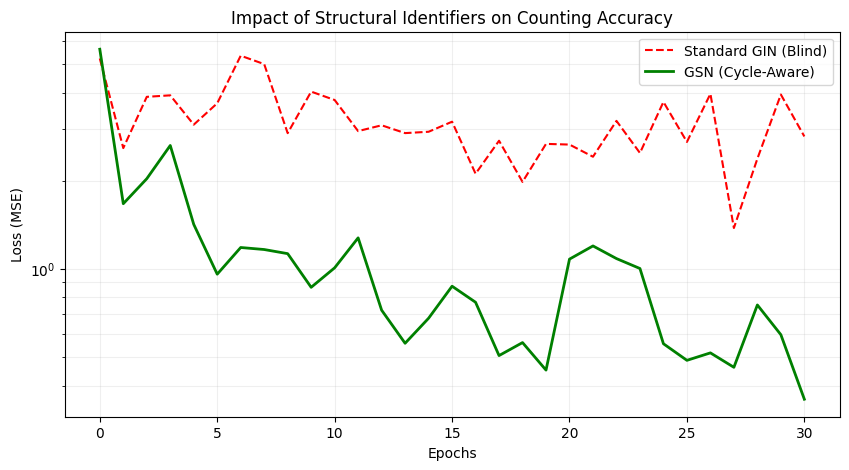

In [65]:
plt.figure(figsize=(10, 5))
plt.plot(loss_baseline, label="Standard GIN (Blind)", color='red', linestyle='--')
plt.plot(loss_gsn, label="GSN (Cycle-Aware)", color='green', linewidth=2)
plt.yscale('log')
plt.title("Impact of Structural Identifiers on Counting Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()